Extracting GDF parameters from BCICIV_2a_gdf\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>
['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
Using matplotlib as 2D backend.


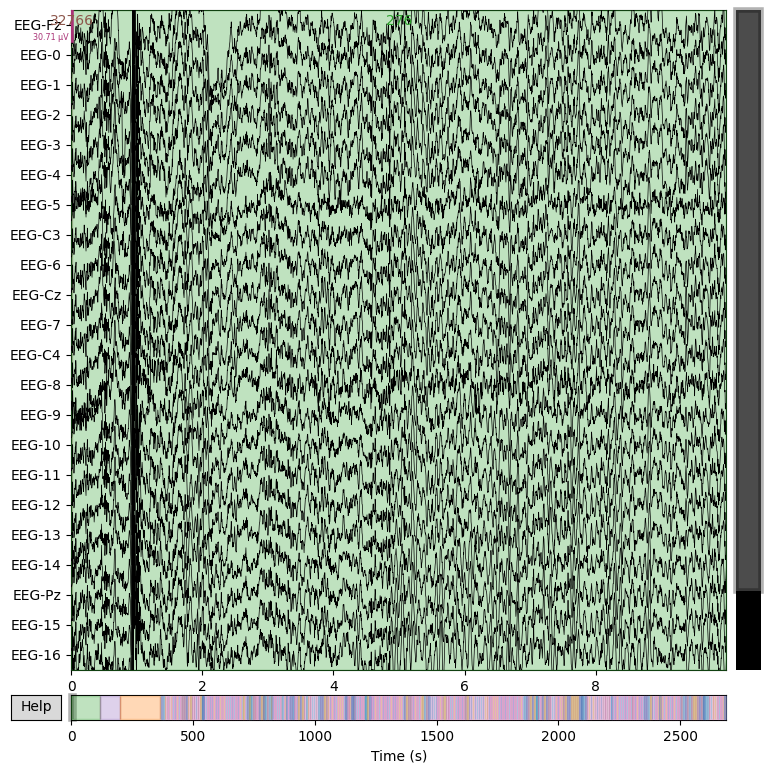

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
1 bad epochs dropped


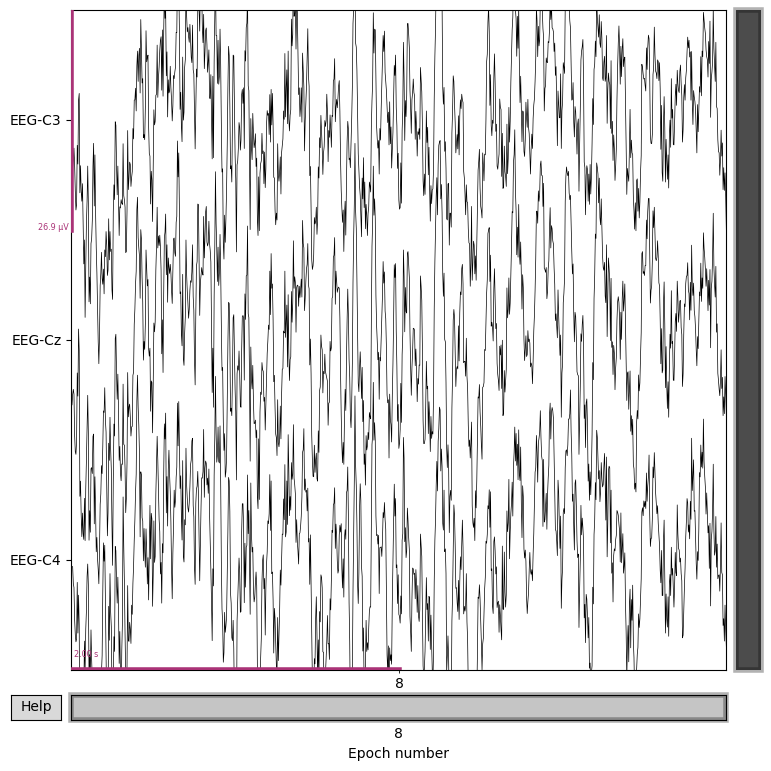

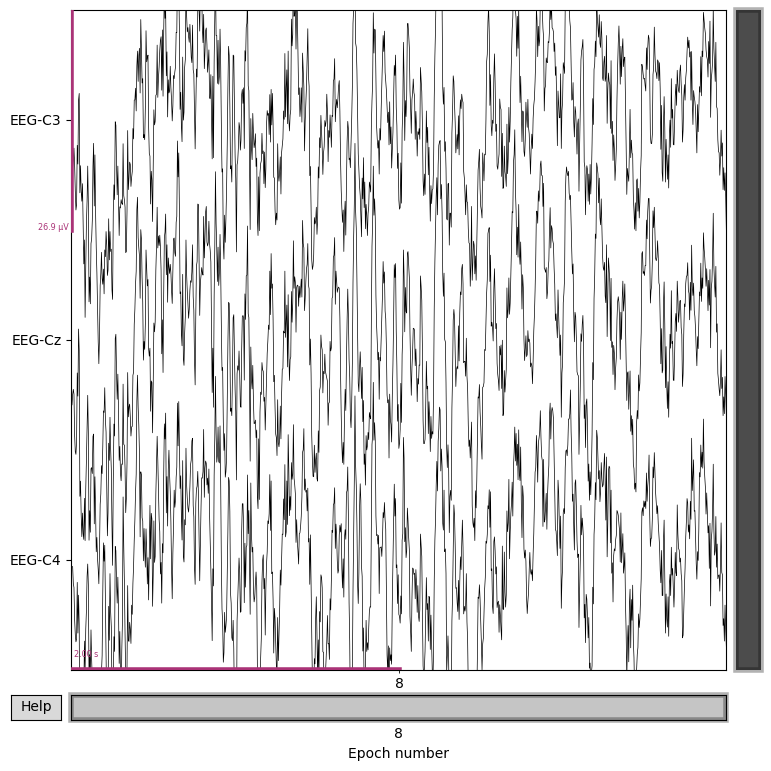

In [1]:
import mne

# Replace with your file path
# file_path = "D:\My Projects\internship\BCICIV_2a_gdf\A01T.gdf"
file_path = "BCICIV_2a_gdf\A01T.gdf"


# Load GDF file
raw = mne.io.read_raw_gdf(file_path, preload=True)

# Basic information
print(raw.info)

# Show channel names
print(raw.ch_names)

# Plot the raw data for the first 10 seconds and all channels
raw.plot(duration=10, n_channels=22, scalings='auto')

# Plot only C3, Cz, and C4 for one trial
selected_channels = ["EEG-C3", "EEG-Cz", "EEG-C4"]
raw.pick(selected_channels)

events, event_dict = mne.events_from_annotations(raw)
available_events = {k: v for k, v in event_dict.items() if k in ["769", "770", "771", "772"]}
epochs = mne.Epochs(raw, events, event_id=available_events, tmin=2, tmax=6, baseline=None, preload=True)

trial_idx = 0  # change this to plot a different trial
epochs[trial_idx].plot(scalings='auto')

Loading EEG data...
Extracting GDF parameters from BCICIV_2a_gdf\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)



Dataset loaded successfully!
<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

Selected Channels:
['EEG-C3', 'EEG-Cz', 'EEG-C4']

Applying 8-30 Hz filter...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Filtering complete.
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]

Event Dictionary:
{np.str_('1023'): 1, np.str

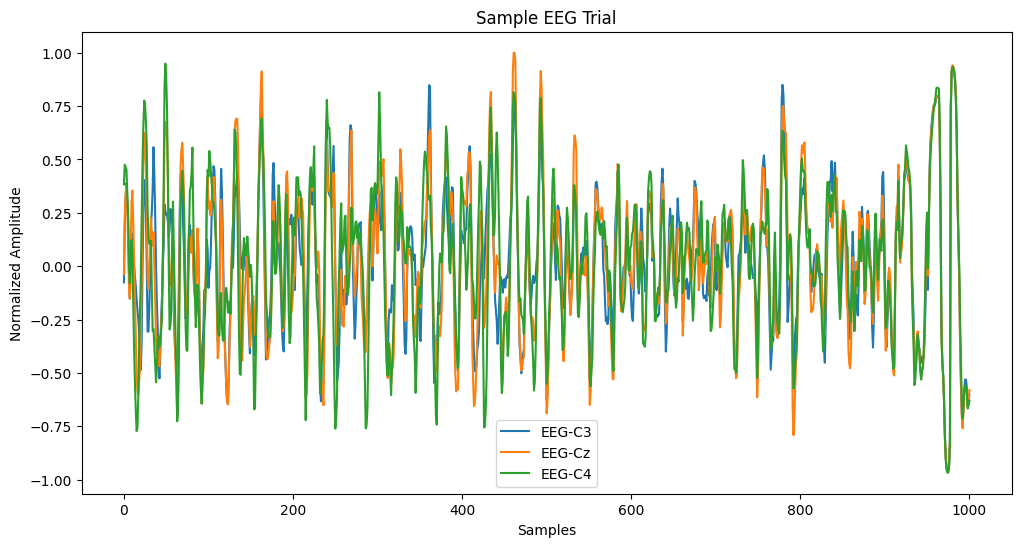


Saved as X_preprocessed.npy


In [4]:
#                Single subject: A01
# ==========================================
# PHASE 1: EEG PREPROCESSING
# BCI Competition IV Dataset 2a
# Using only C3, Cz and C4
# ==========================================

import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ------------------------------------------
# STEP 1: LOAD GDF FILE
# ------------------------------------------

file_path = "BCICIV_2a_gdf\A01T.gdf"

print("Loading EEG data...")

raw = mne.io.read_raw_gdf(file_path, preload=True)

print("\nDataset loaded successfully!")
print(raw)

# ------------------------------------------
# STEP 2: KEEP ONLY C3, Cz, C4
# ------------------------------------------

selected_channels = ["EEG-C3", "EEG-Cz", "EEG-C4"]

raw.pick(selected_channels)

print("\nSelected Channels:")
print(raw.ch_names)

# ------------------------------------------
# STEP 3: BANDPASS FILTER
# Keep only motor imagery frequencies
# 8-30 Hz = Mu + Beta bands
# ------------------------------------------

print("\nApplying 8-30 Hz filter...")

raw.filter(
    l_freq=8,
    h_freq=30
)

print("Filtering complete.")

# ------------------------------------------
# STEP 4: EXTRACT EVENTS
# ------------------------------------------

events, event_dict = mne.events_from_annotations(raw)

print("\nEvent Dictionary:")
print(event_dict)

# ------------------------------------------
# STEP 5: DEFINE MOTOR IMAGERY CLASSES
# ------------------------------------------

event_id = {
    '769': 769,   # Left Hand
    '770': 770,   # Right Hand
    '771': 771,   # Feet
    '772': 772    # Tongue
}

# Keep only events that exist
available_events = {
    k:v for k,v in event_dict.items()
    if k in event_id
}

print("\nAvailable Motor Imagery Events:")
print(available_events)

# ------------------------------------------
# STEP 6: CREATE EPOCHS
# Extract 2s to 6s after cue
# 4 seconds total
# ------------------------------------------

epochs = mne.Epochs(
    raw,
    events,
    event_id=available_events,
    tmin=2.0,
    tmax=6.0,
    baseline=None,
    preload=True
)

# ------------------------------------------
# STEP 7: CONVERT TO NUMPY
# Shape:
# Trials × Channels × Samples
# ------------------------------------------

X = epochs.get_data()

print("\nEpoch Data Shape:")
print(X.shape)

# Example:
# (288, 3, 1000)

# ------------------------------------------
# STEP 8: NORMALIZATION
# Scale values between -1 and 1
# GANs train better on normalized data
# ------------------------------------------

print("\nNormalizing data...")

scaler = MinMaxScaler(feature_range=(-1,1))

X_reshaped = X.reshape(-1, X.shape[-1])

X_norm = scaler.fit_transform(X_reshaped)

X_norm = X_norm.reshape(X.shape)

print("Normalization complete.")

# ------------------------------------------
# STEP 9: VISUALIZE ONE TRIAL
# ------------------------------------------

trial = 0

plt.figure(figsize=(12,6))

for ch in range(3):
    plt.plot(
        X_norm[trial,ch,:],
        label=selected_channels[ch]
    )

plt.title("Sample EEG Trial")
plt.xlabel("Samples")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.show()

# ------------------------------------------
# SAVE FOR PHASE 2
# ------------------------------------------

np.save("X_preprocessed.npy", X_norm)

print("\nSaved as X_preprocessed.npy")

In [ ]:
#                 All subjects: A01-A09

# ==========================================
# PHASE 1: PREPROCESS ALL SUBJECTS
# BCI Competition IV Dataset 2a
# Channels: C3, Cz, C4
# ==========================================

import mne
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Will store data from all subjects
all_X = []
all_y = []

# Loop through subjects 1 to 9
for subject in range(1, 10):

    # Creates filenames:
    # A01T.gdf, A02T.gdf, ..., A09T.gdf
    file_path = f"BCICIV_2a_gdf\A{subject:02d}T.gdf"

    # Load EEG recording
    raw = mne.io.read_raw_gdf(file_path, preload=True)

    # Keep only motor cortex channels
    raw.pick(["EEG-C3", "EEG-Cz", "EEG-C4"])

    # Motor imagery frequency range
    raw.filter(8, 30)

    # Extract event markers
    events, event_dict = mne.events_from_annotations(raw)

    # Keep only motor imagery events
    available_events = {
        k: v for k, v in event_dict.items()
        if k in ["769", "770", "771", "772"]
    }

    # Create trials from 2s to 6s after cue
    epochs = mne.Epochs(
        raw,
        events,
        event_id=available_events,
        tmin=2,
        tmax=6,
        baseline=None,
        preload=True
    )

    # EEG data
    X = epochs.get_data()

    # Labels
    y = epochs.events[:, 2]

    # Store current subject
    all_X.append(X)
    all_y.append(y)

# Combine all subjects

X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

# Normalize EEG values to [-1, 1]

scaler = MinMaxScaler(feature_range=(-1, 1))

X_flat = X.reshape(-1, X.shape[-1])

X_norm = scaler.fit_transform(X_flat)

X_norm = X_norm.reshape(X.shape)

# Save dataset

np.save("X_preprocessed2.npy", X_norm)             # previous run: X_preprocessed.npy
np.save("y.npy", y)

print("Final EEG shape:", X_norm.shape)
print("Final labels shape:", y.shape)

Extracting GDF parameters from BCICIV_2a_gdf\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
1 bad epochs dropped
Extracting GDF parameters from BCICIV

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
1 bad epochs dropped
Extracting GDF parameters from BCICIV

...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
1 bad epochs dropped
Extracting GDF parameters from BCICIV

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
1 bad epochs dropped
Extracting GDF parameters from BCICIV

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
1 bad epochs dropped
Final EEG shape: (2583, 3, 1001)
Fina

In [ ]:
# ==========================================
# PHASE 2: BASELINE CNN CLASSIFIER
# ==========================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

# ------------------------------------------
# STEP 1: LOAD DATA
# ------------------------------------------

X = np.load("X_preprocessed.npy")

print("Loaded EEG data")
print(X.shape)

# ------------------------------------------
# STEP 2: CREATE LABELS
# ------------------------------------------
# IMPORTANT:
# Replace this section later using labels
# extracted from epochs.events
# ------------------------------------------

n_samples = X.shape[0]

y = np.random.randint(0,4,n_samples)

# ------------------------------------------
# STEP 3: CNN INPUT FORMAT
# TensorFlow expects:
# Samples × Timesteps × Features
#
# Current:
# Samples × Channels × Time
#
# Convert:
# Samples × Time × Channels
# ------------------------------------------

X = np.transpose(X,(0,2,1))

print("CNN Input Shape:")
print(X.shape)

# ------------------------------------------
# STEP 4: TRAIN TEST SPLIT
# ------------------------------------------

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# STEP 5: BUILD CNN
# ------------------------------------------

model = Sequential()

model.add(
    Conv1D(
        32,
        kernel_size=5,
        activation='relu',
        input_shape=(1001,3)
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        64,
        kernel_size=5,
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

# ------------------------------------------
# STEP 6: COMPILE
# ------------------------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------
# STEP 7: TRAIN
# ------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# ------------------------------------------
# STEP 8: TEST
# ------------------------------------------

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred,axis=1)

acc = accuracy_score(y_test,y_pred)
prec = precision_score(y_test,y_pred,average='macro')
rec = recall_score(y_test,y_pred,average='macro')
f1 = f1_score(y_test,y_pred,average='macro')

print("\nRESULTS")
print("Accuracy :",acc)
print("Precision:",prec)
print("Recall   :",rec)
print("F1 Score :",f1)